# EDA Lab - Step 1

Load a simple NYC Open Data dataset (Restaurant Inspection Results) and check basic information.

In [1]:
import pandas as pd

# NYC Open Data: Restaurant Inspection Results (simplified columns)
# This keeps the dataset beginner-friendly and easy to read.
url = (
    "https://data.cityofnewyork.us/resource/43nn-pn8j.csv"
    "?$select=camis,dba,boro,cuisine_description,inspection_date,grade,score,critical_flag"
    "&$limit=2000"
)

df = pd.read_csv(url)

# Quick checks
print('Rows, Columns:', df.shape)
print('\nColumn names:')
print(df.columns.tolist())
print('\nFirst 5 rows:')
print(df.head())
print('\nMissing values:')
print(df.isna().sum())

Rows, Columns: (2000, 8)

Column names:
['camis', 'dba', 'boro', 'cuisine_description', 'inspection_date', 'grade', 'score', 'critical_flag']

First 5 rows:
      camis                                   dba       boro  \
0  40557901                   LA ISLA CUCHIFRITOS      Bronx   
1  50104825                               WENDY'S     Queens   
2  40758447                          FULLY GARDEN   Brooklyn   
3  50117192  THE DEVLIN CAFE AT IRISH ARTS CENTER  Manhattan   
4  50088988                              CITY ONE  Manhattan   

  cuisine_description          inspection_date grade  score   critical_flag  
0      Latin American  2023-12-08T00:00:00.000   NaN   58.0        Critical  
1                 NaN  1900-01-01T00:00:00.000   NaN    NaN  Not Applicable  
2                 NaN  1900-01-01T00:00:00.000   NaN    NaN  Not Applicable  
3                 NaN  1900-01-01T00:00:00.000   NaN    NaN  Not Applicable  
4             Chinese  2024-10-29T00:00:00.000   NaN   44.0        C

## Step 2

Simple univariate analysis:
- Histogram of inspection `score`
- Bar chart of restaurants by `boro`

Score summary:
count    1190.000000
mean       24.031933
std        18.244641
min         0.000000
25%        12.000000
50%        20.000000
75%        33.000000
max       128.000000
Name: score, dtype: float64


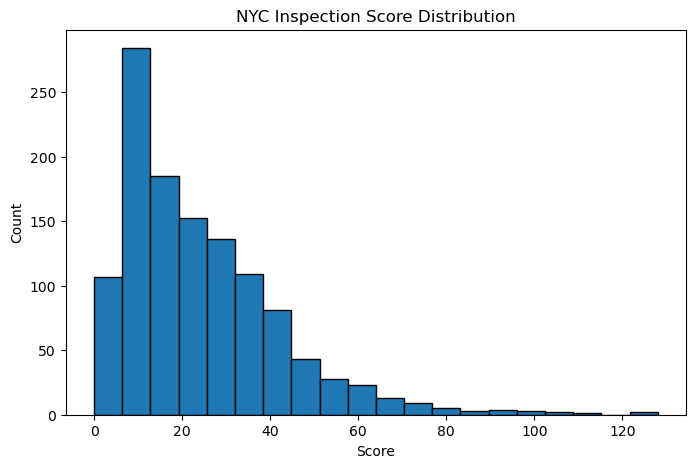

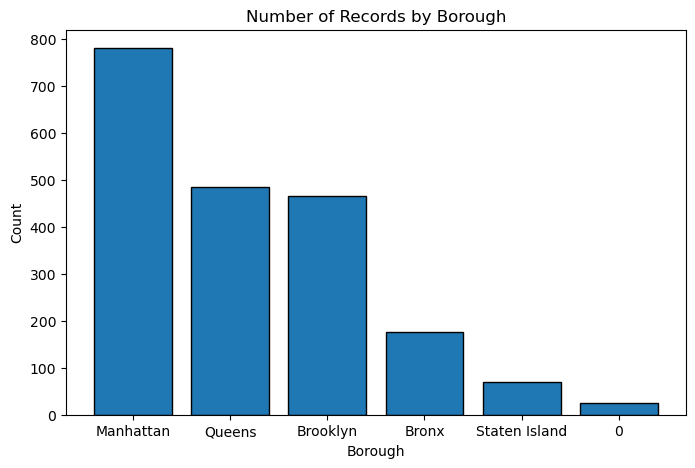


Borough counts:
boro
Manhattan        780
Queens           484
Brooklyn         466
Bronx            177
Staten Island     69
0                 24
Name: count, dtype: int64


In [2]:
import matplotlib.pyplot as plt

# Keep only rows where score exists
score_data = df['score'].dropna()

print('Score summary:')
print(score_data.describe())

# Histogram for score
plt.figure(figsize=(8, 5))
plt.hist(score_data, bins=20, edgecolor='black')
plt.title('NYC Inspection Score Distribution')
plt.xlabel('Score')
plt.ylabel('Count')
plt.show()

# Bar chart for borough counts
boro_counts = df['boro'].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(boro_counts.index, boro_counts.values, edgecolor='black')
plt.title('Number of Records by Borough')
plt.xlabel('Borough')
plt.ylabel('Count')
plt.show()

print('\nBorough counts:')
print(boro_counts)

## Step 3

Simple bivariate analysis:
- Box plot: inspection score by borough

<Figure size 1000x500 with 0 Axes>

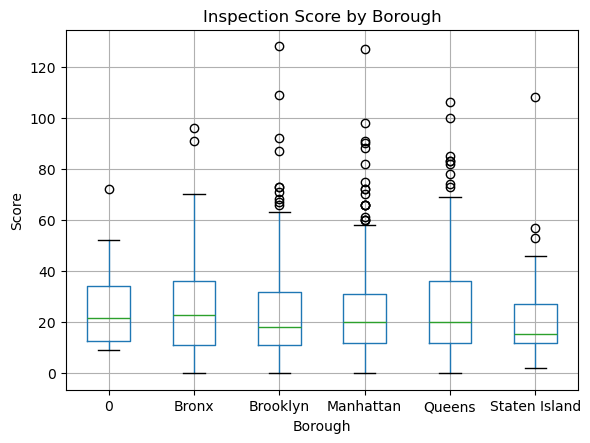

Score statistics by Borough:
               count       mean        std  min    25%   50%    75%    max
boro                                                                      
0               12.0  27.083333  18.846067  9.0  12.75  21.5  34.00   72.0
Bronx          126.0  25.936508  18.265485  0.0  11.25  23.0  36.00   96.0
Brooklyn       269.0  23.754647  19.223335  0.0  11.00  18.0  32.00  128.0
Manhattan      430.0  23.272093  17.377152  0.0  12.00  20.0  31.00  127.0
Queens         313.0  24.661342  18.480421  0.0  12.00  20.0  36.00  106.0
Staten Island   40.0  22.225000  18.906636  2.0  12.00  15.5  27.25  108.0


In [3]:
# Box plot: Score by Borough
data_clean = df[['boro', 'score']].dropna()

plt.figure(figsize=(10, 5))
data_clean.boxplot(column='score', by='boro')
plt.title('Inspection Score by Borough')
plt.suptitle('')
plt.xlabel('Borough')
plt.ylabel('Score')
plt.show()

print('Score statistics by Borough:')
print(data_clean.groupby('boro')['score'].describe())

In [4]:
# Calculate summary statistics
total_records = len(df)
valid_scores = len(df[df['score'].notna()])
valid_pct = (valid_scores / total_records) * 100
score_min = df['score'].min()
score_max = df['score'].max()
score_mean = df['score'].mean()

# Borough analysis
top_borough = df['boro'].value_counts().index[0]
top_borough_count = df['boro'].value_counts().values[0]

# Critical violations
critical_summary = df['critical_flag'].value_counts()

print(f"Total: {total_records}")
print(f"Valid scores: {valid_scores} ({valid_pct:.1f}%)")
print(f"Score range: {score_min}–{score_max} (mean: {score_mean:.2f})")
print(f"Top borough: {top_borough} ({top_borough_count} records)")
print(f"\nCritical violations:\n{critical_summary}")

Total: 2000
Valid scores: 1190 (59.5%)
Score range: 0.0–128.0 (mean: 24.03)
Top borough: Manhattan (780 records)

Critical violations:
critical_flag
Not Applicable    824
Critical          682
Not Critical      494
Name: count, dtype: int64


## Summary

**Dataset Overview:**
- Total records: 2,000
- Valid inspection scores: 1,190 (59.5%)
- Score range: 0–128 (mean: 24.03)

**Key Findings:**
- **Manhattan dominates**: 780 records (39% of dataset)
- **Critical violations**: 682 flagged as "Critical", 494 as "Not Critical", 824 as "Not Applicable"
- **Score distribution**: Right-skewed (most restaurants score 10–20), with outliers up to 128

**Conclusion:**
NYC restaurant inspections show significant variation by borough, with Manhattan having the highest inspection volume and critical violations concentrated in specific establishments.